In [1]:
# =============================================================================
# ИМПОРТ БИБЛИОТЕК
# =============================================================================
import pandas as pd                                # для работы с табличными данными (DataFrame)
import numpy as np                                 # для простановки флагов
from scipy.stats import ttest_ind, mannwhitneyu    # для статистических тестов (t-тест, p-value, тест Манна - Уитни)
import seaborn as sns                              # для красивой визуализации (графики, гистограммы, boxplot, kde)
import matplotlib.pyplot as plt                    # для настройки и отображения графиков (plt.show(), plt.figure и т.д.)

In [2]:
# =============================================================================
# ЗАГРУЗКА ДАННЫХ
# =============================================================================
# Загрузка данных из файла
data = pd.read_excel('retail_ab_test_data.xlsx', sheet_name = 'Данные')
clients = pd.read_excel('retail_ab_test_data.xlsx', sheet_name = 'Clients')
region_dict = pd.read_excel('retail_ab_test_data.xlsx', sheet_name = 'Region_dict')

In [3]:
# Выведем датафрейм 'Данные' для изучения данных
data.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-10-28 04:05:15.221
1,100242,191056.0,4151.0,2022-08-01 02:42:54.992
2,100249,200049.0,5688.0,2022-08-24 12:45:12.744
3,100258,206161.0,4330.0,2022-12-09 15:13:26.437
4,100267,190945.0,5488.0,2022-08-03 02:07:31.468


In [4]:
# =============================================================================
# ПРОВЕРКА ДАННЫХ
# =============================================================================

print('КОЛИЧЕСТВО СТРОЧЕК И СТОЛБЦОВ:', data.shape)
print('')
print('ТИПЫ ДАННЫХ:')
print(data.dtypes)
print('')
print('КОЛИЧЕСТВО ПРОПУСКОВ:')
print(data.isna().sum())
print('')
print('КОЛИЧЕСТВО ДУБЛИКАТОВ:')
print(data.duplicated().sum())

КОЛИЧЕСТВО СТРОЧЕК И СТОЛБЦОВ: (37989, 4)

ТИПЫ ДАННЫХ:
id_order                int64
id_client             float64
amt_payment           float64
dtime_pay      datetime64[ns]
dtype: object

КОЛИЧЕСТВО ПРОПУСКОВ:
id_order          0
id_client       588
amt_payment    2144
dtime_pay      2429
dtype: int64

КОЛИЧЕСТВО ДУБЛИКАТОВ:
0


In [5]:
# Избавляемся от данных с путыми значениями
data = data.dropna()
data.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-10-28 04:05:15.221
1,100242,191056.0,4151.0,2022-08-01 02:42:54.992
2,100249,200049.0,5688.0,2022-08-24 12:45:12.744
3,100258,206161.0,4330.0,2022-12-09 15:13:26.437
4,100267,190945.0,5488.0,2022-08-03 02:07:31.468


In [6]:
# проверим имеют ли некоторые клиенты несколько заказов
data_gr = data.groupby('id_client')['id_order'].count().reset_index().sort_values('id_order', ascending = False)
data_gr.head()

,id_client,id_order
27517,208695.0,10
14849,194825.0,10
1640,180362.0,10
2322,181099.0,10
22570,203282.0,10


### Выводы по таблице 'Данные':  
Итоговые 'Данные' содержит 26973 строк. Некоторые 'id_client' повторяются, т.е. имеют несколько заказов

In [7]:
# Выведем датафрейм 'Clients' для изучения данных
clients.head()

,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015


In [8]:
# =============================================================================
# ПРОВЕРКА ДАННЫХ
# =============================================================================

print('КОЛИЧЕСТВО СТРОЧЕК И СТОЛБЦОВ:', clients.shape)
print('')
print('ТИПЫ ДАННЫХ:')
print(clients.dtypes)
print('')
print('КОЛИЧЕСТВО ПРОПУСКОВ:')
print(clients.isna().sum())
print('')
print('КОЛИЧЕСТВО ДУБЛИКАТОВ:')
print(clients.duplicated().sum())
print('')
print('ПРОВЕРЯЕМ, ЧТО ОДИН ПОЛЬЗОВАТЕЛЬ ПОПАДАЕТ ТОЛЬКО В ОДНУ ГРУППУ (0 ИЛИ 1)')
clients_gr = clients.groupby(['id_client'])['nflag_test'].nunique().reset_index()
bad_id = len(clients_gr[clients_gr['nflag_test'] > 1])
print ('Количество пользователей, присутствущих в обеях группах:', bad_id)

КОЛИЧЕСТВО СТРОЧЕК И СТОЛБЦОВ: (55605, 4)

ТИПЫ ДАННЫХ:
id_client                    int64
dtime_ad            datetime64[ns]
nflag_test                   int64
id_trading_point             int64
dtype: object

КОЛИЧЕСТВО ПРОПУСКОВ:
id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
dtype: int64

КОЛИЧЕСТВО ДУБЛИКАТОВ:
0

ПРОВЕРЯЕМ, ЧТО ОДИН ПОЛЬЗОВАТЕЛЬ ПОПАДАЕТ ТОЛЬКО В ОДНУ ГРУППУ (0 ИЛИ 1)
Количество пользователей, присутствущих в обеях группах: 0


In [9]:
# Посмотим, сколько у нас 'id_clients'
print('Количество id_client:', len(clients))

Количество id_client: 55605


In [10]:
# Выведем строки с пропусками
clients_null = clients[clients.isna().any(axis=1)]
clients_null

,id_client,dtime_ad,nflag_test,id_trading_point
1,193942,NaT,0,13
73,201705,NaT,1,13
563,201492,NaT,0,13
656,201280,NaT,1,13
681,178805,NaT,0,23
...,...,...,...,...
54053,205998,NaT,0,13
54487,187572,NaT,1,23
54577,193029,NaT,1,23
55015,203724,NaT,1,13


In [11]:
# Избавляемся от данных с путыми значениями
clients = clients.dropna()
clients

,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015
5,254313,2022-06-19 22:18:01.770,1,453
...,...,...,...,...
55600,193038,2022-07-09 00:31:25.196,0,1015
55601,244069,2022-08-08 00:12:31.319,1,991
55602,189084,2022-06-29 04:34:42.610,1,439
55603,182758,2022-06-13 11:28:37.856,1,573


In [12]:
# Посмотим, сколько у нас осталось клиентов
print('Количество id_client:', len(clients))

Количество id_client: 55356


### Выводы по таблице 'Clients':
Итоговые данные в 'Clients' содержит 55356 строк. Каждый 'id_client' находится в одной своей группе. Пересечений нет.

In [13]:
# Выведем датафрейм 'Region_dict' для изучения данных
region_dict.head()

,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир


In [14]:
# =============================================================================
# ПРОВЕРКА ДАННЫХ
# =============================================================================

print('КОЛИЧЕСТВО СТРОЧЕК И СТОЛБЦОВ:', region_dict.shape)
print('')
print('ТИПЫ ДАННЫХ:')
print(region_dict.dtypes)
print('')
print('КОЛИЧЕСТВО ПРОПУСКОВ:')
print(region_dict.isna().sum())
print('')
print('КОЛИЧЕСТВО ДУБЛИКАТОВ:')
print(region_dict.duplicated().sum())


КОЛИЧЕСТВО СТРОЧЕК И СТОЛБЦОВ: (66, 2)

ТИПЫ ДАННЫХ:
id_trading_point     int64
city                object
dtype: object

КОЛИЧЕСТВО ПРОПУСКОВ:
id_trading_point    0
city                0
dtype: int64

КОЛИЧЕСТВО ДУБЛИКАТОВ:
0


In [15]:
# Посмотрим города, где проводился тест и сколько в каждом городе торговых точек
region_dict.groupby('city')['id_trading_point'].nunique().reset_index()

,city,id_trading_point
0,Великий Новгород,1
1,Владимир,1
2,Волгоград,1
3,Дмитров,1
4,Казань,6
5,Краснодар,4
6,Красноярск,5
7,Москва,11
8,Мурманск,2
9,Нижний Новгород,1


### Выводы по таблице 'Region_dict':
Итоговые данные в 'Region_dict' нормальные: пропусков, дубликатов нет. В некоторых городах присутствуют несколько торговых точек.

In [16]:
# У нас в data - 26973 заказов, а в clients - 55356 клиентов, поэтому делаем 'outer join'
df = data.merge(clients, on = 'id_client', how = 'outer')
# Присоединяем 'region_dict' только с теми торговыми точками, которые есть в объединённом data и clients
df = df.merge(region_dict, on = 'id_trading_point', how = 'inner')
df.head()

,id_order,id_client,amt_payment,dtime_pay,dtime_ad,nflag_test,id_trading_point,city
0,244553.0,178561.0,3052.0,2022-06-11 04:59:15.220,2022-06-03 02:47:49.183,0,453,Санкт-Петербург
1,169709.0,178562.0,2439.0,2022-06-17 00:06:30.469,2022-06-03 02:51:21.878,0,2652,Москва
2,121122.0,178563.0,768.0,2022-10-09 03:59:15.396,2022-06-03 02:52:10.616,1,112,Санкт-Петербург
3,NaN,178564.0,NaN,NaT,2022-06-03 02:53:10.089,1,26,Ростов-на-Дону
4,174130.0,178565.0,958.0,2022-08-24 20:18:53.796,2022-06-03 02:55:13.525,1,739,Новосибирск


In [17]:
# группируем по 'id_client','id_trading_point','city
# вычисляем количество заказов и сумму платежей по ним
df_gr = df.groupby(['id_client','id_trading_point','city']).agg({'id_order':'count', 'amt_payment':'sum'}).reset_index()
df_gr

,id_client,id_trading_point,city,id_order,amt_payment
0,178561.0,453,Санкт-Петербург,1,3052.0
1,178562.0,2652,Москва,1,2439.0
2,178563.0,112,Санкт-Петербург,1,768.0
3,178564.0,26,Ростов-на-Дону,0,0.0
4,178565.0,739,Новосибирск,1,958.0
...,...,...,...,...,...
55351,331949.0,573,Санкт-Петербург,0,0.0
55352,331950.0,1654,Москва,0,0.0
55353,331954.0,544,Казань,0,0.0
55354,331955.0,72,Сочи,0,0.0


In [18]:
# добавим к финальной таблице столбец 'nflag_test' из таблицы 'clients'
df_final = df_gr.merge(clients[['id_client','nflag_test']], on = 'id_client')
df_final

,id_client,id_trading_point,city,id_order,amt_payment,nflag_test
0,178561.0,453,Санкт-Петербург,1,3052.0,0
1,178562.0,2652,Москва,1,2439.0,0
2,178563.0,112,Санкт-Петербург,1,768.0,1
3,178564.0,26,Ростов-на-Дону,0,0.0,1
4,178565.0,739,Новосибирск,1,958.0,1
...,...,...,...,...,...,...
55351,331949.0,573,Санкт-Петербург,0,0.0,1
55352,331950.0,1654,Москва,0,0.0,1
55353,331954.0,544,Казань,0,0.0,0
55354,331955.0,72,Сочи,0,0.0,0


In [19]:
# проставим флаг оплаты
df_final['nflag_paid'] = np.where(df_final['amt_payment'] > 0, 1, 0)
df_final.head()

,id_client,id_trading_point,city,id_order,amt_payment,nflag_test,nflag_paid
0,178561.0,453,Санкт-Петербург,1,3052.0,0,1
1,178562.0,2652,Москва,1,2439.0,0,1
2,178563.0,112,Санкт-Петербург,1,768.0,1,1
3,178564.0,26,Ростов-на-Дону,0,0.0,1,0
4,178565.0,739,Новосибирск,1,958.0,1,1


In [20]:
# создадим список торговых точек с пустыми оплатами

zero_payment_points = []

for i in df_final['id_trading_point'].unique():
    # Фильтрация данных для текущей торговой точки
    filtered_df = df_final[df_final['id_trading_point'] == i]
    
    # Суммы платежей для nflag_test = 0 и nflag_test = 1
    sum_a = filtered_df.loc[filtered_df['nflag_test'] == 0, 'amt_payment'].sum()
    sum_b = filtered_df.loc[filtered_df['nflag_test'] == 1, 'amt_payment'].sum()
    
    # Проверка условия и добавление в список
    if sum_a == 0 or sum_b == 0:
        zero_payment_points.append(i)

print(zero_payment_points)

[np.int64(26), np.int64(739), np.int64(866), np.int64(46), np.int64(1099), np.int64(1015), np.int64(603), np.int64(810), np.int64(800), np.int64(228), np.int64(1), np.int64(13), np.int64(23), np.int64(4), np.int64(7)]


In [21]:
# создадим список торговых точек, где в одной из групп отсутствуют наблюдения
empty_group_points = []

for i in df_final['id_trading_point'].unique():
    # Фильтрация и подсчет клиентов в контрольной группе
    c_a = df_final.loc[(df_final['id_trading_point'] == i) & (df_final['nflag_test'] == 0), 'id_client'].count()
    # Фильтрация и подсчет клиентов в тестовой группе
    c_b = df_final.loc[(df_final['id_trading_point'] == i) & (df_final['nflag_test'] == 1), 'id_client'].count()
    # Проверка и добавление в список
    if (c_a == 0) | (c_b == 0):
        empty_group_points.append(i)

print(empty_group_points)

[np.int64(739), np.int64(866), np.int64(1099), np.int64(1015), np.int64(603), np.int64(810), np.int64(800), np.int64(228)]


In [22]:
# Создадим финальный датафрейм, из которого исключим эти торговые точки
df_fin = df_final[~df_final['id_trading_point'].isin(empty_group_points + zero_payment_points)]
df_fin.head()

,id_client,id_trading_point,city,id_order,amt_payment,nflag_test,nflag_paid
0,178561.0,453,Санкт-Петербург,1,3052.0,0,1
1,178562.0,2652,Москва,1,2439.0,0,1
2,178563.0,112,Санкт-Петербург,1,768.0,1,1
6,178567.0,453,Санкт-Петербург,1,2663.0,0,1
7,178568.0,3786,Москва,3,13537.0,1,1


In [23]:
# =============================================================================
# ФИНАЛЬНАЯ ПРОВЕРКА ДАННЫХ
# =============================================================================

print('КОЛИЧЕСТВО СТРОЧЕК И СТОЛБЦОВ:', df_fin.shape)
print('')
print('ТИПЫ ДАННЫХ:')
print(df_fin.dtypes)
print('')
print('КОЛИЧЕСТВО ПРОПУСКОВ:')
print(df_fin.isna().sum())
print('')
print('КОЛИЧЕСТВО ДУБЛИКАТОВ:')
print(df_fin.duplicated().sum())
print('ПРОВЕРЯЕМ, ЧТО ОДИН ПОЛЬЗОВАТЕЛЬ ПОПАДАЕТ ТОЛЬКО В ОДНУ ГРУППУ (0 ИЛИ 1)')
df_fin_gr = df_fin.groupby(['id_client'])['nflag_test'].nunique().reset_index()
bad_id = len(df_fin_gr[df_fin_gr['nflag_test'] > 1])
print ('Количество пользователей, присутствущих в обеях группах:', bad_id)

КОЛИЧЕСТВО СТРОЧЕК И СТОЛБЦОВ: (45318, 7)

ТИПЫ ДАННЫХ:
id_client           float64
id_trading_point      int64
city                 object
id_order              int64
amt_payment         float64
nflag_test            int64
nflag_paid            int64
dtype: object

КОЛИЧЕСТВО ПРОПУСКОВ:
id_client           0
id_trading_point    0
city                0
id_order            0
amt_payment         0
nflag_test          0
nflag_paid          0
dtype: int64

КОЛИЧЕСТВО ДУБЛИКАТОВ:
0
ПРОВЕРЯЕМ, ЧТО ОДИН ПОЛЬЗОВАТЕЛЬ ПОПАДАЕТ ТОЛЬКО В ОДНУ ГРУППУ (0 ИЛИ 1)
Количество пользователей, присутствущих в обеях группах: 0


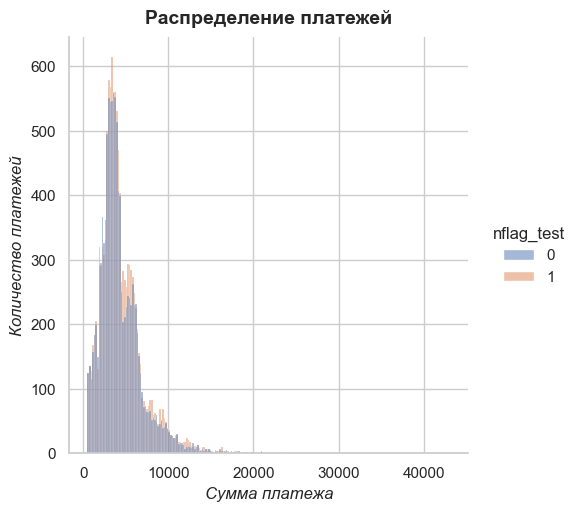

In [24]:
# Визуализация распределений платежей:

# для улучшения визуализации
sns.set(style="whitegrid", rc={"figure.figsize": (15, 5)})

sns.displot(df_fin[df_fin['amt_payment'] > 0], x = 'amt_payment', hue = 'nflag_test')

# Устанавливаем заголовок графика с текстом "Распределение платежей",
# размером шрифта 14, жирным весом и отступом 10 пунктов
plt.title('Распределение платежей', fontsize='14',fontweight='bold', pad=10)

# Добавляем подпись к осям X и Y размером шрифта 12,
# нормальным весом и курсивным стилем
plt.xlabel('Сумма платежа', fontsize='12', fontweight='normal', style='italic')
plt.ylabel('Количество платежей', fontsize='12', fontweight='normal', style='italic')

plt.show()

### ВЫВОДЫ:
1. Данные очищены и готовы к проведению тестов
2. Типы данных нормальные: числа и даты. Город соответственно object
3. Дубликатов и пользователей, которые попали одновременно в тестовую и контрольную группу нет

## <u>A/B-тест</u>

#### 1. <u>Продутовая гипотеза:</u>  
Уведомление о новых товарах и скидках с помощью пуш-уведомления в приложении увеличивает конверсию в покупку и средний чек

#### 2. <u>Таргет-метрики:</u>  
- Конверсия из рекламы в покупку
- Средний чек покупки

#### 3. <u>Статистические гипотезы:</u>  
**H<sub>0</sub>:** Конверсия и средний чек в группе A = конверсия и средний чек в группе B  
**H<sub>1</sub>:** Конверсия и средний чек в группе B > конверсия и средний чек в группе A


#### 4. <u>A/B-тест:</u>

In [25]:
# создадим функции для тестов
def test_calc(r1, r2, alpha = 0.05):

    s,p = ttest_ind(r1,r2)

    if p < alpha:
        print("Гипотеза H0 отвергается. Средние статистически значимо различаются")
        print("Разница средних = ", r1.mean()-r2.mean())
    else:
        print("Гипотеза H0 не отвергается. Разница статистически не значима")
        print("Разница средних = 0")

    return s, p

def mann_whitney_func(r1, r2, alpha=.05):

    s, p = mannwhitneyu(r1, r2)

    if p<alpha:
        print('Распределения не равны')
    else:
        print('Распределения равны')

    return s, p

In [26]:
# разделяем группы A и B для тестов

df_a = df_fin[df_fin['nflag_test']==0]
df_b = df_fin[df_fin['nflag_test']==1]

print()
print('ГРУППЫ ДЛЯ ТЕСТОВ:')
print()
print('Группа A (контрольная) — пользователи получают уведомления в форме баннера')
print()
display(df_a.head())
print()
print('Группа B (тестовая) — пользователи получают уведомления в форме пуш-уведомления')
print()
display(df_b.head())
print()


ГРУППЫ ДЛЯ ТЕСТОВ:

Группа A (контрольная) — пользователи получают уведомления в форме баннера



,id_client,id_trading_point,city,id_order,amt_payment,nflag_test,nflag_paid
0,178561.0,453,Санкт-Петербург,1,3052.0,0,1
1,178562.0,2652,Москва,1,2439.0,0,1
6,178567.0,453,Санкт-Петербург,1,2663.0,0,1
8,178569.0,117,Санкт-Петербург,1,2008.0,0,1
11,178572.0,88,Тольятти,1,1828.0,0,1



Группа B (тестовая) — пользователи получают уведомления в форме пуш-уведомления



,id_client,id_trading_point,city,id_order,amt_payment,nflag_test,nflag_paid
2,178563.0,112,Санкт-Петербург,1,768.0,1,1
7,178568.0,3786,Москва,3,13537.0,1,1
9,178570.0,80,Саратов,2,6651.0,1,1
10,178571.0,2652,Москва,1,3063.0,1,1
12,178573.0,80,Саратов,0,0.0,1,0


In [27]:
print("t-test абсолютные платежи")
test_calc(df_a['amt_payment'], df_b['amt_payment'])
print()
print("t-test конверсия в платеж")
test_calc(df_a['nflag_paid'], df_b['nflag_paid'])
print()
print("Тест Манна-Уитни")
mann_whitney_func(df_a['amt_payment'], df_b['amt_payment'])

t-test абсолютные платежи
Гипотеза H0 отвергается. Средние статистически значимо различаются
Разница средних =  -263.088912844727

t-test конверсия в платеж
Гипотеза H0 отвергается. Средние статистически значимо различаются
Разница средних =  -0.043524040271688325

Тест Манна-Уитни
Распределения не равны


(np.float64(243344369.0), np.float64(3.008345273971901e-24))

#### 5. <u>Сегментация результатов A/B-теста:</u>


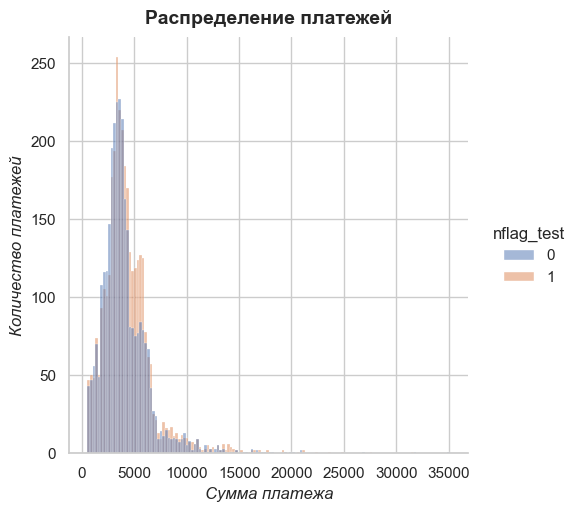

t-test абсолютные платежи
Гипотеза H0 отвергается. Средние статистически значимо различаются
Разница средних =  381.7784892750842

t-test конверсия в платеж
Гипотеза H0 отвергается. Средние статистически значимо различаются
Разница средних =  0.05557800593933432

Тест Манна-Уитни
Распределения не равны


(np.float64(20595574.5), np.float64(7.010591402203484e-16))

In [28]:
#Москва
df_msk = df_fin[df_fin['city']=='Москва']

# Визуализация распределений платежей:
sns.set(style="whitegrid", rc={"figure.figsize": (15, 5)})
sns.displot(df_msk[df_msk['amt_payment'] > 0], x = 'amt_payment', hue = 'nflag_test')

plt.title('Распределение платежей', fontsize='14',fontweight='bold', pad=10)
plt.xlabel('Сумма платежа', fontsize='12', fontweight='normal', style='italic')
plt.ylabel('Количество платежей', fontsize='12', fontweight='normal', style='italic')

plt.show()

# Выполняем t-тесты для города
print("t-test абсолютные платежи")
test_calc(df_msk[df_msk['nflag_test']==1]['amt_payment'], df_msk[df_msk['nflag_test']==0]['amt_payment'])
print()
print("t-test конверсия в платеж")
test_calc(df_msk[df_msk['nflag_test']==1]['nflag_paid'], df_msk[df_msk['nflag_test']==0]['nflag_paid'])
print()
print("Тест Манна-Уитни")
mann_whitney_func(df_msk[df_msk['nflag_test']==1]['amt_payment'], df_msk[df_msk['nflag_test']==0]['amt_payment'])

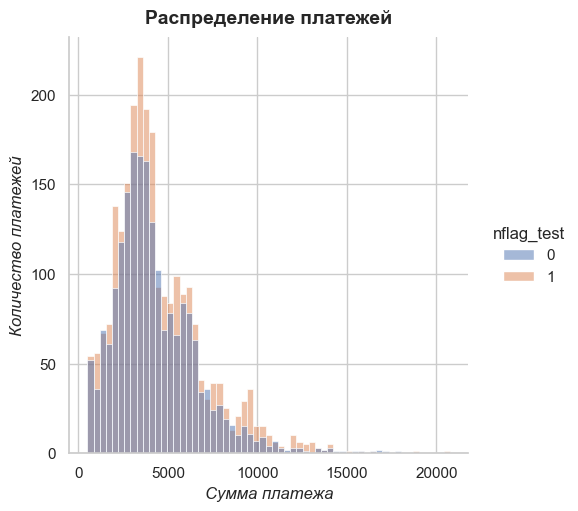

t-test абсолютные платежи
Гипотеза H0 отвергается. Средние статистически значимо различаются
Разница средних =  513.9039043833998

t-test конверсия в платеж
Гипотеза H0 отвергается. Средние статистически значимо различаются
Разница средних =  0.09877797751600403

Тест Манна-Уитни
Распределения не равны


(np.float64(10899685.5), np.float64(2.0392184217953754e-20))

In [29]:
#Санкт-Петербург
df_spb = df_fin[df_fin['city']=='Санкт-Петербург']

sns.set(style="whitegrid", rc={"figure.figsize": (15, 5)})
sns.displot(df_spb[df_spb['amt_payment'] > 0], x = 'amt_payment', hue = 'nflag_test')

plt.title('Распределение платежей', fontsize='14',fontweight='bold', pad=10)
plt.xlabel('Сумма платежа', fontsize='12', fontweight='normal', style='italic')
plt.ylabel('Количество платежей', fontsize='12', fontweight='normal', style='italic')

plt.show()

# Выполняем t-тесты для города
print("t-test абсолютные платежи")
test_calc(df_spb[df_spb['nflag_test']==1]['amt_payment'], df_spb[df_spb['nflag_test']==0]['amt_payment'])
print()
print("t-test конверсия в платеж")
test_calc(df_spb[df_spb['nflag_test']==1]['nflag_paid'], df_spb[df_spb['nflag_test']==0]['nflag_paid'])
print()
print("Тест Манна-Уитни")
mann_whitney_func(df_spb[df_spb['nflag_test']==1]['amt_payment'], df_spb[df_spb['nflag_test']==0]['amt_payment'])

Саратов



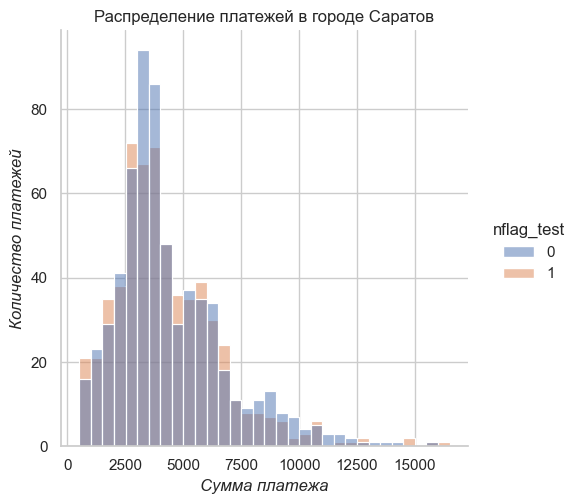

- по платежам:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
- по конверсии:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
Тест Манна-Уитни
Распределения равны

Тольятти



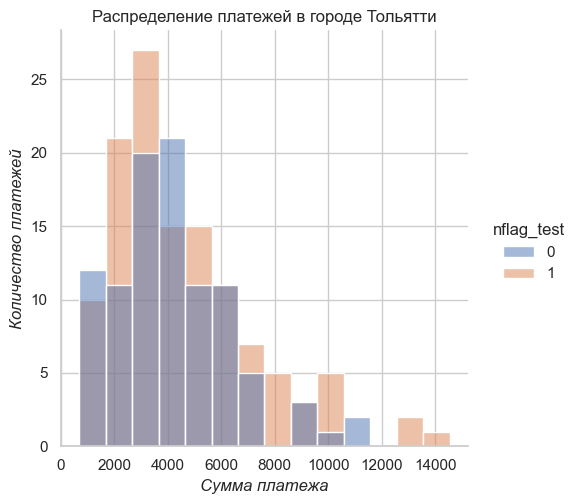

- по платежам:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
- по конверсии:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
Тест Манна-Уитни
Распределения равны

Владимир



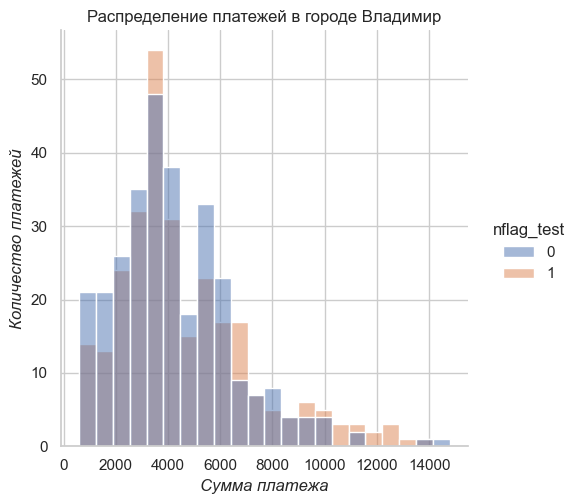

- по платежам:
Гипотеза H0 отвергается. Средние статистически значимо различаются
Разница средних =  -438.6098419243094
- по конверсии:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
Тест Манна-Уитни
Распределения не равны

Мурманск



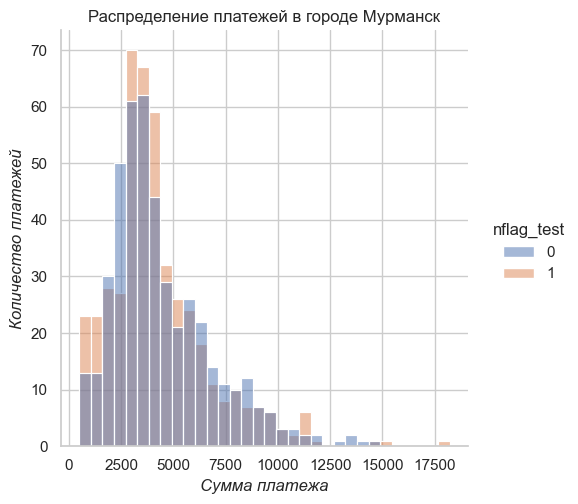

- по платежам:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
- по конверсии:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
Тест Манна-Уитни
Распределения равны

Красноярск



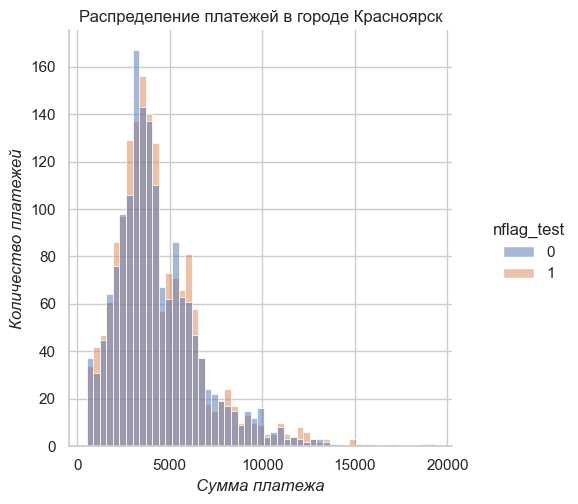

- по платежам:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
- по конверсии:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
Тест Манна-Уитни
Распределения равны

Казань



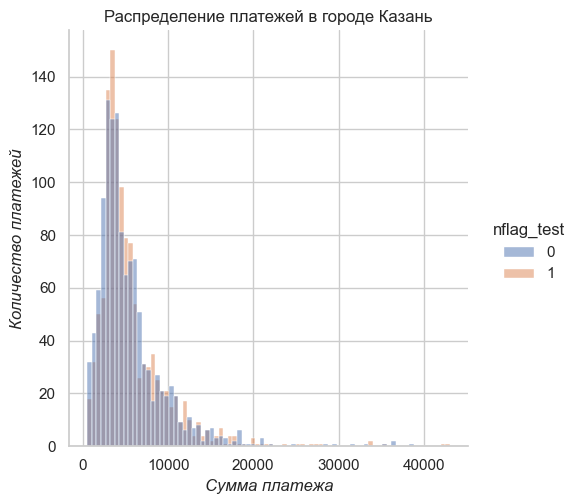

- по платежам:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
- по конверсии:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
Тест Манна-Уитни
Распределения равны

Самара



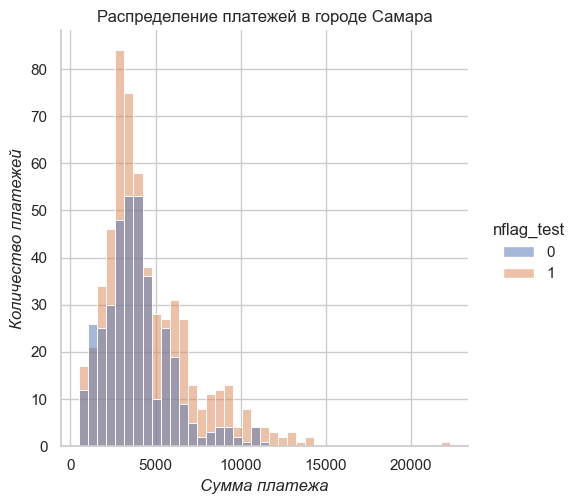

- по платежам:
Гипотеза H0 отвергается. Средние статистически значимо различаются
Разница средних =  -1544.3720191247648
- по конверсии:
Гипотеза H0 отвергается. Средние статистически значимо различаются
Разница средних =  -0.2772412939282998
Тест Манна-Уитни
Распределения не равны

Волгоград



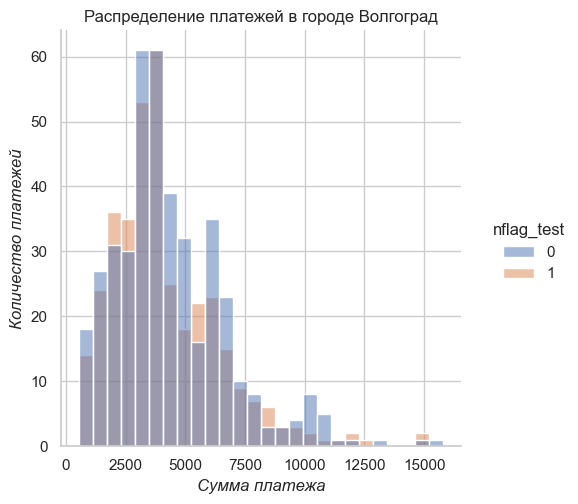

- по платежам:
Гипотеза H0 отвергается. Средние статистически значимо различаются
Разница средних =  312.89040013337035
- по конверсии:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
Тест Манна-Уитни
Распределения не равны

Сочи



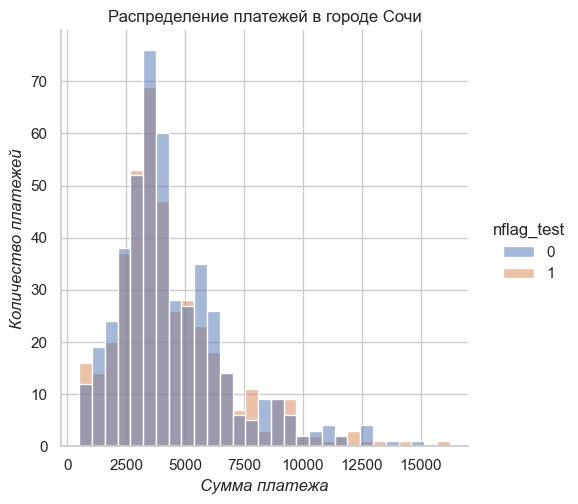

- по платежам:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
- по конверсии:
Гипотеза H0 отвергается. Средние статистически значимо различаются
Разница средних =  0.04931605920420967
Тест Манна-Уитни
Распределения равны

Краснодар



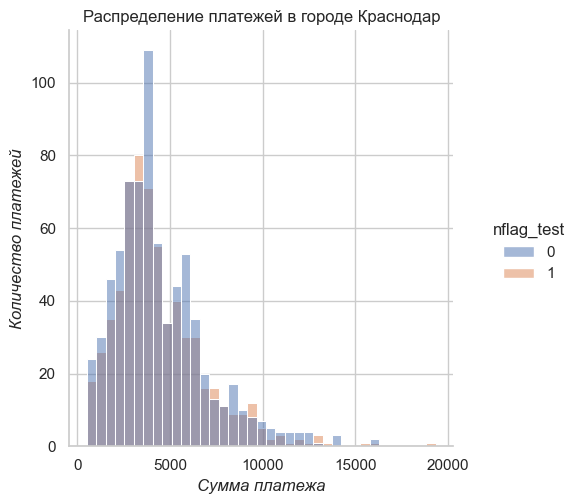

- по платежам:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
- по конверсии:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
Тест Манна-Уитни
Распределения равны

Дмитров



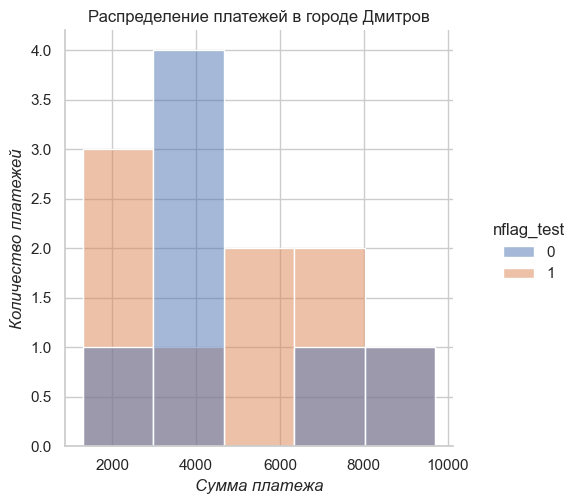

- по платежам:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
- по конверсии:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
Тест Манна-Уитни
Распределения равны

Тюмень



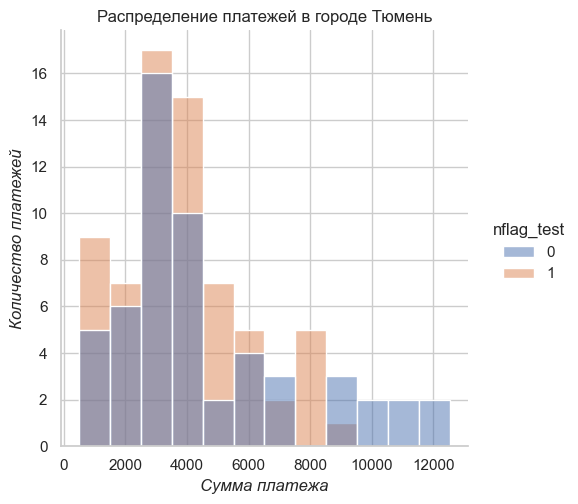

- по платежам:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
- по конверсии:
Гипотеза H0 отвергается. Средние статистически значимо различаются
Разница средних =  -0.1463645943097998
Тест Манна-Уитни
Распределения не равны

Сахалинск



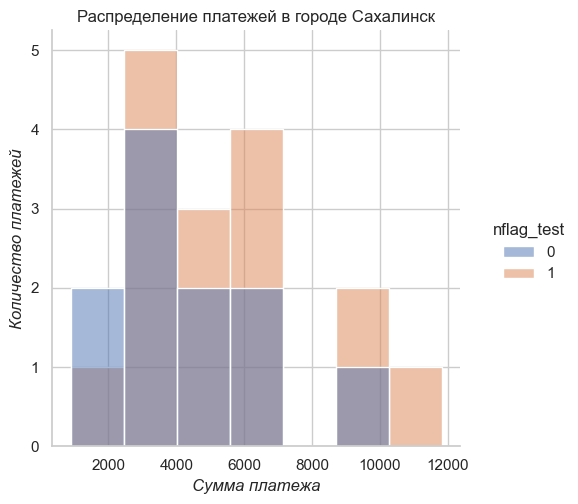

- по платежам:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
- по конверсии:
Гипотеза H0 не отвергается. Разница статистически не значима
Разница средних = 0
Тест Манна-Уитни
Распределения равны



In [30]:
# список крупных городов
cities_big = ['Москва', 'Санкт-Петербург']

# список других городов
other_cities = [city for city in df_fin['city'].unique() if city not in cities_big]

for city in other_cities:
    df_city = df_fin[df_fin['city'] == city]
    print(f"{city}\n")
    
    # Визуализация распределений платежей:
    sns.set(style="whitegrid", rc={"figure.figsize": (15, 5)})
    sns.displot(df_city[df_city['amt_payment'] > 0], x = 'amt_payment', hue = 'nflag_test')
    plt.title(f"Распределение платежей в городе {city}")
    plt.xlabel('Сумма платежа', fontsize='12', fontweight='normal', style='italic')
    plt.ylabel('Количество платежей', fontsize='12', fontweight='normal', style='italic')
    plt.show()

    # Выполняем t-тесты для города
    print('- по платежам:')
    test_calc(df_city[df_city['nflag_test'] == 0]['amt_payment'],
              df_city[df_city['nflag_test'] == 1]['amt_payment'])
    print('- по конверсии:')
    test_calc(df_city[df_city['nflag_test'] == 0]['nflag_paid'],
              df_city[df_city['nflag_test'] == 1]['nflag_paid'])
    print("Тест Манна-Уитни")
    mann_whitney_func(df_city[df_city['nflag_test']==1]['amt_payment'], 
                      df_city[df_city['nflag_test']==0]['amt_payment'])
    print()


### Выводы: 
1. Санкт-Петербург, Москва, Самара. 
Уведомление о новых товарах и скидках с помощью пуш-уведомления в приложении увеличило конверсию в покупку и средний чек
2. Владимир, Волгоград 
Уведомление о новых товарах и скидках с помощью пуш-уведомления в приложении увеличило средний чек, но не увеличило конверсию в покупку.
3. Сочи, Тюмень
Уведомление о новых товарах и скидках с помощью пуш-уведомления в приложении не увеличило средний чек, но увеличило конверсию в покупку.
4. Саратов, Тольятти, Мурманск, Красноярск, Казань, Краснодар, Дмитров, Сахалинск.  
Уведомление о новых товарах и скидках с помощью пуш-уведомления в приложении не увеличило конверсию в покупку и средний чек

Мы имеем большое количество выводов по городам. Для финальных результатов по городам создадим калькулятор в Excel

## <u>Таблица для создания калькулятора в Excel</u>

Поля итоговой таблицы:

city — город.  
id_trading_point — уникальный идентификатор торговой точки, к которой прикреплен данный пользователь.  
count_test — кол-во наблюдений в тестовой группе.   
count_control — кол-во наблюдений в контрольной группе.  
count_all — суммарное кол-во наблюдений.  
percent_count — процент кол-ва наблюдений данной ТТ от всех наблюдений.  
avg_payment_test — средний платеж в тестовой группе.  
avg_payment_control — средний платеж в контрольной группе.  
diff — разница между средними платежами.  
sigma_test — стандартное отклонение платежей в тестовой группе.  
sigma_control — стандартное отклонение платежей в контрольной группе.  
ttest — значение статистического критерия (критерий Стьюдента для сравнения средних платежей).  
pvalue_ttest — pvalue статистического критерия (критерий Стьюдента для сравнения средних платежей).  

In [31]:
df_fin.head()

,id_client,id_trading_point,city,id_order,amt_payment,nflag_test,nflag_paid
0,178561.0,453,Санкт-Петербург,1,3052.0,0,1
1,178562.0,2652,Москва,1,2439.0,0,1
2,178563.0,112,Санкт-Петербург,1,768.0,1,1
6,178567.0,453,Санкт-Петербург,1,2663.0,0,1
7,178568.0,3786,Москва,3,13537.0,1,1


In [32]:
# Таблица для калькулятора

# Формируем таблицу на агрегации столбцов city, id_trading_point
# Разделим на 2 группы (А и В), чтобы правильно посчитать кол-во наблюдений и средние платжи в группах

df_excel_a = df_fin[
    (df_fin['nflag_test'] == 1)
].groupby(['city', 'id_trading_point']).agg(
    count_test=('id_client', 'nunique'),
    avg_payment_test=('amt_payment', 'mean')
).reset_index()

df_excel_b = df_fin[
    (df_fin['nflag_test'] == 0)
].groupby(['city', 'id_trading_point']).agg(
    count_control=('id_client', 'nunique'),
    avg_payment_control=('amt_payment', 'mean')
).reset_index()

# Объеденим таблицы в одну
df_excel = df_excel_a.merge(df_excel_b, on = ['city', 'id_trading_point'], how = 'outer')

# Формируем столбец  count_all — суммарное кол-во наблюдений
df_excel['count_all'] = df_excel['count_test'] + df_excel['count_control'] 

# Формируем столбец  percent_count — процент кол-ва наблюдений данной ТТ от всех наблюдений
df_excel['percent_count'] = df_excel['count_all'] / df_excel['count_all'].sum()

# Формируем столбец  diff — разница между средними платежами.
df_excel['diff'] = df_excel['avg_payment_test'] - df_excel['avg_payment_control'] 

# Формируем столбцы sigma_test, sigma_control, ttest и pvalue_ttest

# Создаём пустые списки
sigma_a       = []  # 
sigma_b       = []  # 
ttest         = []  # 
pvalue_ttest  = []  #

for i in df_excel['id_trading_point']:
    
    x = df_fin[(df_fin['id_trading_point'] == i) & (df_fin['nflag_test'] == 0)]['amt_payment']
    y = df_fin[(df_fin['id_trading_point'] == i) & (df_fin['nflag_test'] == 1)]['amt_payment']

    sigma_a.append(x.std())
    sigma_b.append(y.std())
    s, p = ttest_ind(x, y)

    ttest.append(s)
    pvalue_ttest.append(p)    

df_excel['sigma_control'] = sigma_a
df_excel['sigma_test']    = sigma_b
df_excel['ttest']         = ttest
df_excel['pvalue_ttest']  = pvalue_ttest

df_excel.head()

,city,id_trading_point,count_test,avg_payment_test,count_control,avg_payment_control,count_all,percent_count,diff,sigma_control,sigma_test,ttest,pvalue_ttest
0,Владимир,11,509,2547.220039,608,2108.610197,1117,0.024648,438.609842,2663.038392,3023.702164,-2.576955,0.010095
1,Волгоград,66,657,2288.870624,703,2601.761024,1360,0.030010,-312.890400,2830.193773,2682.567610,2.089272,0.036869
2,Дмитров,2,78,579.333333,71,483.450704,149,0.003288,95.882629,1654.923182,1860.762430,-0.331052,0.741076
3,Казань,439,355,2481.960563,351,2400.635328,706,0.015579,81.325236,3722.117072,4040.441007,-0.278067,0.781042
4,Казань,477,382,2259.623037,386,2496.987047,768,0.016947,-237.364010,3881.994719,3482.846094,0.891593,0.372891


In [33]:
# Проставляем флаги

df_excel['label'] = np.where((df_excel['diff'] > 0) & (df_excel['pvalue_ttest'] < 0.05), 'Положительный исход',
                             np.where((df_excel['diff'] < 0) & (df_excel['pvalue_ttest'] < 0.05), 'Отрицательный исход'
                                      , 'Нейтральный исход'))
df_excel.head()

,city,id_trading_point,count_test,avg_payment_test,count_control,avg_payment_control,count_all,percent_count,diff,sigma_control,sigma_test,ttest,pvalue_ttest,label
0,Владимир,11,509,2547.220039,608,2108.610197,1117,0.024648,438.609842,2663.038392,3023.702164,-2.576955,0.010095,Положительный исход
1,Волгоград,66,657,2288.870624,703,2601.761024,1360,0.030010,-312.890400,2830.193773,2682.567610,2.089272,0.036869,Отрицательный исход
2,Дмитров,2,78,579.333333,71,483.450704,149,0.003288,95.882629,1654.923182,1860.762430,-0.331052,0.741076,Нейтральный исход
3,Казань,439,355,2481.960563,351,2400.635328,706,0.015579,81.325236,3722.117072,4040.441007,-0.278067,0.781042,Нейтральный исход
4,Казань,477,382,2259.623037,386,2496.987047,768,0.016947,-237.364010,3881.994719,3482.846094,0.891593,0.372891,Нейтральный исход


In [34]:
df1 = df_excel[df_excel['label'] == 'Положительный исход']
df2 = df_excel[df_excel['label'] == 'Отрицательный исход']
df3 = df_excel[df_excel['label'] == 'Нейтральный исход']

writer = pd.ExcelWriter("retail_ab_test_calculator.xlsx", engine="xlsxwriter")

df1.to_excel(writer, sheet_name="Положительный исход")
df2.to_excel(writer, sheet_name="Отрицательный исход")
df3.to_excel(writer, sheet_name="Нейтральный исход")

writer.close()